<a href="https://colab.research.google.com/github/wilmar-barragan/Deep-Learning-week15-Manipulaci-n-de-Datos-Monitoreo-y-Logging-y-Model-Serving-con-Weights-Biases/blob/main/Manipulaci%C3%B3n_de_Datos%2C_Monitoreo_y_Logging.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

   Data Journey: Ciclo de Vida de los Datos
1. **Origen**: Dataset público `Breast Cancer Wisconsin` (scikit-learn). Contiene 569 muestras, 30 características numéricas y etiqueta binaria (benigno/maligno).
2. **Acceso**: Carga directa vía API de scikit-learn. No requiere autenticación ni descarga manual.
3. **Preparación**:
   - Verificación de valores faltantes (ninguno en este dataset)
   - Estandarización con `StandardScaler`
   - División train/validation/test (70/15/15)
4. **Uso en el modelo**: Los datos estandarizados alimentan un MLP simple en PyTorch. El flujo garantiza reproducibilidad y evita data leakage.
5. **Post-entrenamiento**: Los datos de validación se usan para early stopping; los de prueba para evaluación final. En producción, se esperaría monitoreo de drift y reentrenamiento periódico.

In [2]:
# 1: Instalación de dependencias

# Ejecutar una sola vez
!pip install wandb scikit-learn pandas numpy matplotlib torch torchvision tqdm -q

In [3]:
# Acceso, manipulación y división de datos

import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Carga
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# 2. Exploración rápida
print(f"📊 Dimensiones: {X.shape}")
print(f"✅ Nulos: {X.isnull().sum().sum()}")
print(f"🔢 Clases: {pd.Series(y).value_counts().to_dict()}")

# 3. División estratificada
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# 4. Estandarización (ajuste solo en train)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# Conversión a tensores
import torch
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32).unsqueeze(1)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

print("✅ Datos listos para entrenamiento.")

📊 Dimensiones: (569, 30)
✅ Nulos: 0
🔢 Clases: {1: 357, 0: 212}
✅ Datos listos para entrenamiento.


In [6]:
# Definición del modelo

import torch.nn as nn

class SimpleMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

input_dim = X_train.shape[1]
model = SimpleMLP(input_dim)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [4]:
#Integración con Weights & Biases
import wandb

# 🔑 INICIALIZACIÓN W&B
# Reemplaza "TU_API_KEY" si es necesario, o ejecuta `!wandb login` en una celda aparte
wandb.login()  # Se abrirá un prompt para pegar tu API key (obtenla en https://wandb.ai/authorize)

wandb.init(
    project="ciclo-vida-datos-modelo",
    name="mlp-breast-cancer-baseline",
    config={
        "learning_rate": 0.001,
        "epochs": 20,
        "batch_size": 32,
        "optimizer": "Adam",
        "architecture": "MLP-64-32-1",
        "dataset": "Breast Cancer (sklearn)",
        "early_stopping_patience": 5
    }
)

print("🟢 W&B inicializado. Dashboard: https://wandb.ai/" + wandb.run.entity + "/ciclo-vida-datos-modelo")

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 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


wandb: WARNING Invalid choice
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: sanin134135 (sanin134135-university-the-cundinamarca) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


🟢 W&B inicializado. Dashboard: https://wandb.ai/sanin134135-university-the-cundinamarca/ciclo-vida-datos-modelo


In [7]:
# Entrenamiento con logging

from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import torch

# DataLoader
train_ds = TensorDataset(X_train_t, y_train_t)
val_ds = TensorDataset(X_val_t, y_val_t)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=len(X_val_t), shuffle=False)

# Entrenamiento
best_val_loss = np.inf
patience = 5
trigger_times = 0

for epoch in range(20):
    model.train()
    epoch_loss = 0
    correct = 0
    total = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item() * xb.size(0)
        correct += ((preds > 0.5).float() == yb).sum().item()
        total += xb.size(0)

    train_loss = epoch_loss / total
    train_acc = correct / total

    # Validación
    model.eval()
    with torch.no_grad():
        val_preds = model(X_val_t)
        val_loss = criterion(val_preds, y_val_t).item()
        val_acc = ((val_preds > 0.5).float() == y_val_t).sum().item() / len(y_val_t)

    # 📊 LOGGING EN W&B
    wandb.log({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_accuracy": train_acc,
        "val_loss": val_loss,
        "val_accuracy": val_acc,
        "learning_rate": optimizer.param_groups[0]['lr']
    })

    # Early stopping
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        trigger_times = 0
        torch.save(model.state_dict(), "best_model.pth")
        wandb.save("best_model.pth")
    else:
        trigger_times += 1
        if trigger_times >= patience:
            print(f"⏹️ Early stopping en epoch {epoch+1}")
            break

    print(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")

wandb.finish()
print("✅ Entrenamiento finalizado. Resultados sincronizados con W&B.")

wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Epoch 01 | Train Loss: 0.6211 | Val Loss: 0.5568 | Val Acc: 0.9294
Epoch 02 | Train Loss: 0.4912 | Val Loss: 0.4238 | Val Acc: 0.9529
Epoch 03 | Train Loss: 0.3439 | Val Loss: 0.2814 | Val Acc: 0.9529
Epoch 04 | Train Loss: 0.2202 | Val Loss: 0.1792 | Val Acc: 0.9529
Epoch 05 | Train Loss: 0.1561 | Val Loss: 0.1246 | Val Acc: 0.9529
Epoch 06 | Train Loss: 0.1190 | Val Loss: 0.0965 | Val Acc: 0.9882
Epoch 07 | Train Loss: 0.0984 | Val Loss: 0.0794 | Val Acc: 0.9882
Epoch 08 | Train Loss: 0.0890 | Val Loss: 0.0704 | Val Acc: 0.9882
Epoch 09 | Train Loss: 0.0792 | Val Loss: 0.0669 | Val Acc: 0.9882
Epoch 10 | Train Loss: 0.0725 | Val Loss: 0.0640 | Val Acc: 0.9882
Epoch 11 | Train Loss: 0.0675 | Val Loss: 0.0608 | Val Acc: 0.9882
Epoch 12 | Train Loss: 0.0670 | Val Loss: 0.0594 | Val Acc: 0.9765
Epoch 13 | Train Loss: 0.0587 | Val Loss: 0.0554 | Val Acc: 0.9765
Epoch 14 | Train Loss: 0.0588 | Val Loss: 0.0534 | Val Acc: 0.9765
Epoch 15 | Train Loss: 0.0599 | Val Loss: 0.0549 | Val Acc: 0.

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
learning_rate,▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
train_accuracy,▁▆▆▆▆▇▇▇▇███████████
train_loss,█▆▅▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁
val_accuracy,▁▄▄▄▄██████▇▇▇▇▇▇▇▇▇
val_loss,█▆▄▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
epoch,20
learning_rate,0.001
train_accuracy,0.98744
train_loss,0.04943
val_accuracy,0.97647


✅ Entrenamiento finalizado. Resultados sincronizados con W&B.


In [11]:
# Evaluación en test
model.load_state_dict(torch.load("best_model.pth"))
model.eval()
with torch.no_grad():
    test_preds = model(X_test_t)
    test_loss = criterion(test_preds, y_test_t).item()
    test_acc = ((test_preds > 0.5).float() == y_test_t).sum().item() / len(y_test_t)

print(f"🎯 Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.4f}")

# Guardar artefacto en W&B (opcional pero recomendado)
# wandb.log_model("best_model.pth", "model_v1")

🎯 Test Loss: 0.0989 | Test Accuracy: 0.9535


##  Análisis de Métricas y Valor del Monitoreo
- **Overfitting**: Si `train_acc >> val_acc`, el modelo memoriza. El logging permite detectarlo tempranamente.
- **Estabilidad**: Gráficas suaves de pérdida indican learning rate adecuado. Picos o oscilaciones sugieren necesidad de ajustar batch size o usar scheduler.
- **Trazabilidad**: W&B registra hiperparámetros, métricas por epoch, pesos del modelo y entorno. Esto garantiza reproducibilidad y auditoría.
- **Decisión de despliegue**: Solo se despliega un modelo con métricas estables en validación y sin sobreajuste significativo.

In [12]:
# Ejemplo mínimo de serialización para serving
import joblib
# En producción, se usaría FastAPI + torch.load o ONNX
joblib.dump(scaler, "scaler.pkl")
torch.save(model.state_dict(), "model_weights.pth")
print("📦 Artefactos listos para serving: scaler.pkl, model_weights.pth")

📦 Artefactos listos para serving: scaler.pkl, model_weights.pth


## Conclusiones Técnicas
- **Aprendizajes**: El ciclo de vida del modelo va más allá del entrenamiento. La trazabilidad con W&B permite comparar experimentos, detectar overfitting y auditar decisiones.
- **Dificultades**: Sincronizar métricas en tiempo real requiere estructura clara de logging. El manejo de escalado y serialización exige atención a versiones de dependencias.
- **Oportunidades**: Implementar CI/CD para ML, integrar monitoreo de drift (Evidently AI, WhyLabs), y automatizar reentrenamiento con pipelines (Airflow, MLflow).
- **Trabajo en equipo**: Dividir roles (ingeniería de datos, modelado, MLOps, documentación) acelera el desarrollo y mejora la calidad del entregable.

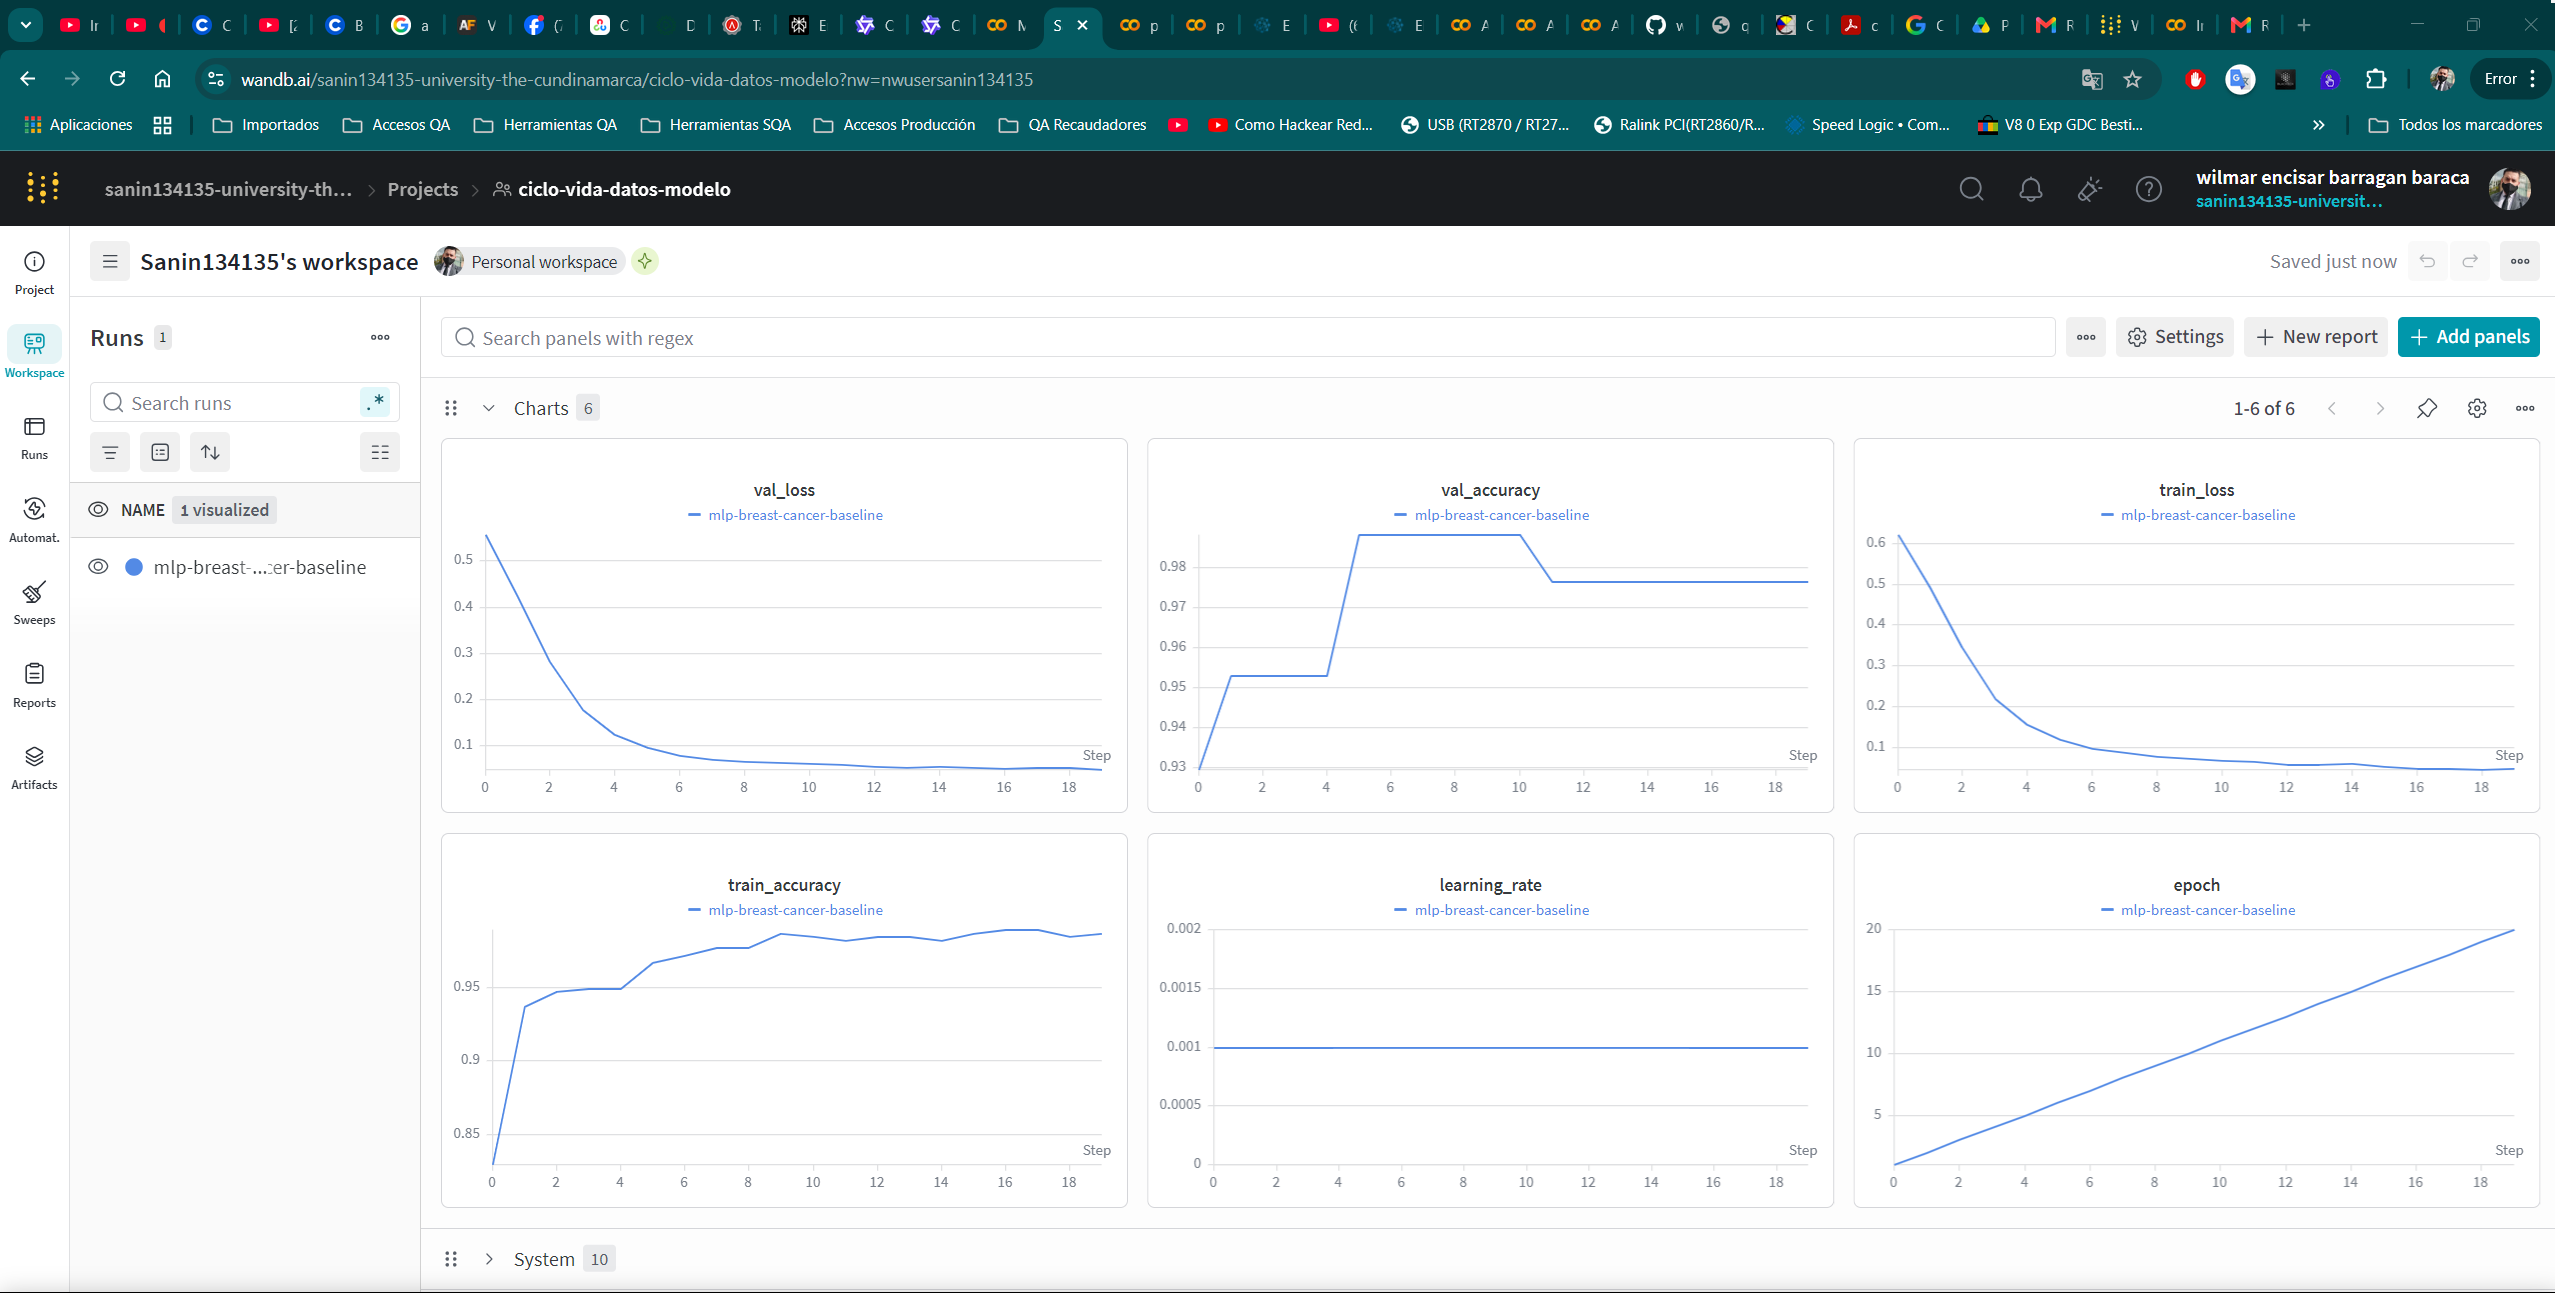